# Notebook 01d: Monthly Tile Panel

## README

### What this notebook does
Reads the daily modelling panel produced by `01c` for each city and aggregates
it to **one row per `city × spatial_id × month`** by averaging all valid daily
values within each calendar month.

### Aggregation rules
| Column | Rule | Notes |
|---|---|---|
| `no2` | mean of valid days | NaN days excluded from mean |
| `era5_temp` | mean of valid days | NaN days excluded from mean |
| `tci` | mean of valid days | NaN days excluded from mean |
| `n_days_no2` | count of non-NaN days | coverage diagnostic |
| `n_days_temp` | count of non-NaN days | coverage diagnostic |
| `n_days_tci` | count of non-NaN days | coverage diagnostic |
| `n_days_total` | total calendar days in month | denominator for coverage % |

### Inclusion rule
A tile × month row is **kept** if it has at least 1 valid day for each of NO₂,
temperature, and TCI. Tile × months with zero valid days on any feature are dropped.
Coverage statistics are shown so the analyst can apply stricter thresholds downstream.

### Outputs (per city)
`data/processed/{city}/grid_panel/{city}_monthly_tile_panel.csv`

### Centroid join
Tile centroids (`centroid_lon`, `centroid_lat`) are joined from
`data/processed/{city}/grid/grid_{city}_1km_centroids.csv`
for use in the spatial model downstream.

## 0. Setup

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

def find_project_root(start: Path, marker: str = 'src') -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find '{marker}/' above {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from calendar import month_abbr

print('✓ Libraries loaded')

✓ Libraries loaded


## 1. USER INPUTS

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# USER INPUTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATA_ROOT = PROJECT_ROOT / 'data' / 'processed'

CITIES = [ # We selected the subset for which we had all data (i.e., TCI)
    # 'baghdad',
    # 'buenos_aires',
    # 'mexico_city',
    # 'new_york',
    # 'mumbai',
    # 'lima',
    # 'dakar',
    'cairo'
]

# Column names in the daily panel
CITY_COL       = 'city'
DATE_COL       = 'date'
SPATIAL_ID_COL = 'spatial_id'
NO2_COL        = 'no2'
TEMP_COL       = 'era5_temp'#_global'
TCI_COL        = 'tci'

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MONTH_NAMES = {i: month_abbr[i] for i in range(1, 13)}
print(f'Cities to process: {CITIES}')

Cities to process: ['cairo']


## 2. Aggregation Loop

In [5]:
def load_daily_panel(city: str) -> pd.DataFrame:
    path = DATA_ROOT / city / 'grid_panel' / f'{city}_modelling_panel.csv.gz'
    df   = pd.read_csv(path, parse_dates=[DATE_COL])
    df['month'] = df[DATE_COL].dt.month
    df['year']  = df[DATE_COL].dt.year
    return df


def load_centroids(city: str) -> pd.DataFrame:
    path = DATA_ROOT / city / 'grid' / f'grid_{city}_1km_centroids.csv'
    return pd.read_csv(path)[['spatial_id', 'centroid_lon', 'centroid_lat']]


def aggregate_monthly(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate daily panel to monthly means per tile.
    Coverage columns count non-NaN days per feature.
    n_days_total = calendar days in that month × year combination.
    """
    grp = df.groupby([CITY_COL, SPATIAL_ID_COL, 'year', 'month'])
    

    agg = grp.agg(
        no2          = (NO2_COL,  'mean'),
        era5_temp    = (TEMP_COL, 'mean'),
        tci          = (TCI_COL,  'mean'),
        n_days_no2   = (NO2_COL,  'count'),   # count ignores NaN
        n_days_temp  = (TEMP_COL, 'count'),
        n_days_tci   = (TCI_COL,  'count'),
    ).reset_index()

    # Total calendar days in each year-month
    agg['n_days_total'] = pd.to_datetime(
        agg[['year','month']].assign(day=1)
    ).dt.days_in_month

    # Coverage percentages
    agg['cov_no2_pct']  = 100 * agg['n_days_no2']  / agg['n_days_total']
    agg['cov_temp_pct'] = 100 * agg['n_days_temp'] / agg['n_days_total']
    agg['cov_tci_pct']  = 100 * agg['n_days_tci']  / agg['n_days_total']

    # Drop rows with zero valid days on any feature
    before = len(agg)
    agg = agg[
        (agg['n_days_no2']  > 0) &
        (agg['n_days_temp'] > 0) &
        (agg['n_days_tci']  > 0)
    ].copy()
    print(f'  Dropped {before - len(agg):,} tile-months with zero coverage on at least one feature')

    return agg


all_city_panels = {}   # city → monthly DataFrame (for cross-city plots)

for city in CITIES:
    print(f'\n── {city.upper()} ──────────────────────────────────────────')

    # ── Load ──────────────────────────────────────────────────────────────────
    daily = load_daily_panel(city)
    print(f'  Daily rows : {len(daily):,}  |  '
          f'tiles: {daily[SPATIAL_ID_COL].nunique():,}  |  '
          f'dates: {daily[DATE_COL].min().date()} → {daily[DATE_COL].max().date()}')

    # ── Aggregate ─────────────────────────────────────────────────────────────
    monthly = aggregate_monthly(daily)
    print(f'  Monthly rows: {len(monthly):,}  |  '
          f'tile-months: {len(monthly):,}  |  '
          f'months: {sorted(monthly["month"].unique())}')

    # ── Join centroids ─────────────────────────────────────────────────────────
    try:
        centroids = load_centroids(city)
        before    = len(monthly)
        monthly   = monthly.merge(centroids, on=SPATIAL_ID_COL, how='left')
        missing   = monthly[['centroid_lon','centroid_lat']].isna().any(axis=1).sum()
        print(f'  Centroids joined  |  {missing} tiles missing centroid (will be NaN)')
    except FileNotFoundError:
        print(f'  ⚠ Centroid file not found — centroid columns will be absent')
        monthly['centroid_lon'] = np.nan
        monthly['centroid_lat'] = np.nan

    # ── Save ──────────────────────────────────────────────────────────────────
    out_path = DATA_ROOT / city / 'grid_panel' / f'{city}_monthly_tile_panel.csv'
    monthly.to_csv(out_path, index=False)
    print(f'  ✓ Saved → {out_path}')

    all_city_panels[city] = monthly

print('\n✓ All cities processed')


── CAIRO ──────────────────────────────────────────
  Daily rows : 455,521  |  tiles: 4,041  |  dates: 2025-01-01 → 2025-12-18
  Dropped 721 tile-months with zero coverage on at least one feature
  Monthly rows: 39,515  |  tile-months: 39,515  |  months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  Centroids joined  |  0 tiles missing centroid (will be NaN)
  ✓ Saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/cairo/grid_panel/cairo_monthly_tile_panel.csv

✓ All cities processed


## 3. Coverage Statistics

In [6]:
# ── 3.1 Per-city coverage summary table ───────────────────────────────────────
for city, monthly in all_city_panels.items():
    print(f'\n═══ {city.upper()} — Coverage Summary ═══════════════════════════════')
    summary = (
        monthly.groupby('month')
        .agg(
            n_tile_months   = (SPATIAL_ID_COL, 'count'),
            mean_cov_no2    = ('cov_no2_pct',  'mean'),
            mean_cov_temp   = ('cov_temp_pct', 'mean'),
            mean_cov_tci    = ('cov_tci_pct',  'mean'),
            median_days_no2 = ('n_days_no2',   'median'),
            median_days_tci = ('n_days_tci',   'median'),
        )
        .round(1)
        .rename(index=MONTH_NAMES)
        .reset_index()
        .rename(columns={'month': 'Month'})
    )
    print(summary.to_string(index=False))


═══ CAIRO — Coverage Summary ═══════════════════════════════
Month  n_tile_months  mean_cov_no2  mean_cov_temp  mean_cov_tci  median_days_no2  median_days_tci
  Jan           3359          37.7           47.3          47.3             10.0             13.0
  Feb           3298          33.2           48.1          48.1              8.0             13.0
  Mar           3319          35.2           44.6          44.6              9.0             12.0
  Apr           3287          37.8           44.4          44.4             10.0             12.0
  May           3345          39.3           45.4          45.4             11.0             13.0
  Jun           3435          39.9           40.0          40.0             10.0             10.0
  Jul           3086          22.8           22.9          22.9              5.0              5.0
  Aug           3371          30.4           30.5          30.5              8.0              8.0
  Sep           3344          32.5           33.5       

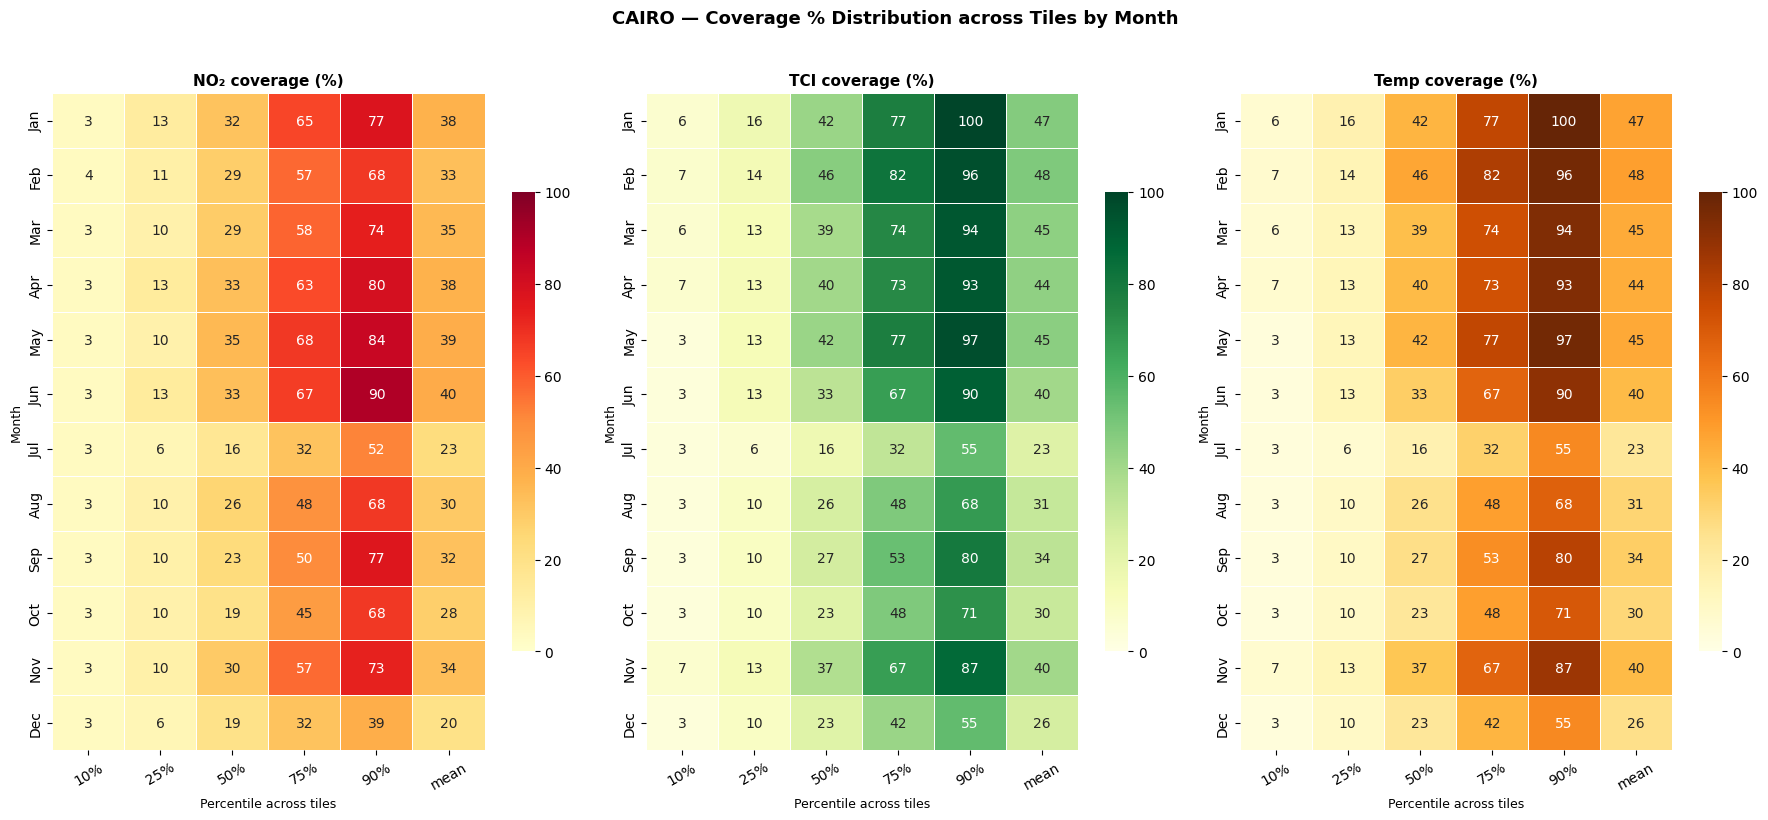

In [7]:
# ── 3.2 Coverage heatmaps per city ────────────────────────────────────────────
for city, monthly in all_city_panels.items():

    fig, axes = plt.subplots(1, 3, figsize=(18, max(4, monthly['month'].nunique() * 0.5 + 2)))

    for ax, col, label, cmap in zip(
            axes,
            ['cov_no2_pct', 'cov_tci_pct', 'cov_temp_pct'],
            ['NO₂ coverage (%)', 'TCI coverage (%)', 'Temp coverage (%)'],
            ['YlOrRd', 'YlGn', 'YlOrBr']):

        # Pivot: rows = month, cols = decile of spatial_id (too many tiles for individual cols)
        # Show distribution as % of tiles with >X days
        pivot = (
            monthly.groupby('month')[col]
                   .describe(percentiles=[.1,.25,.5,.75,.9])
                   [['10%','25%','50%','75%','90%','mean']]
                   .rename(index=MONTH_NAMES)
        )
        sns.heatmap(pivot, ax=ax, annot=True, fmt='.0f',
                    cmap=cmap, vmin=0, vmax=100,
                    linewidths=0.5, cbar_kws={'shrink': 0.7})
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('Percentile across tiles', fontsize=9)
        ax.set_ylabel('Month', fontsize=9)
        ax.tick_params(axis='x', rotation=30)

    fig.suptitle(f'{city.upper()} — Coverage % Distribution across Tiles by Month',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / city / 'grid_panel' / f'{city}_coverage_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()

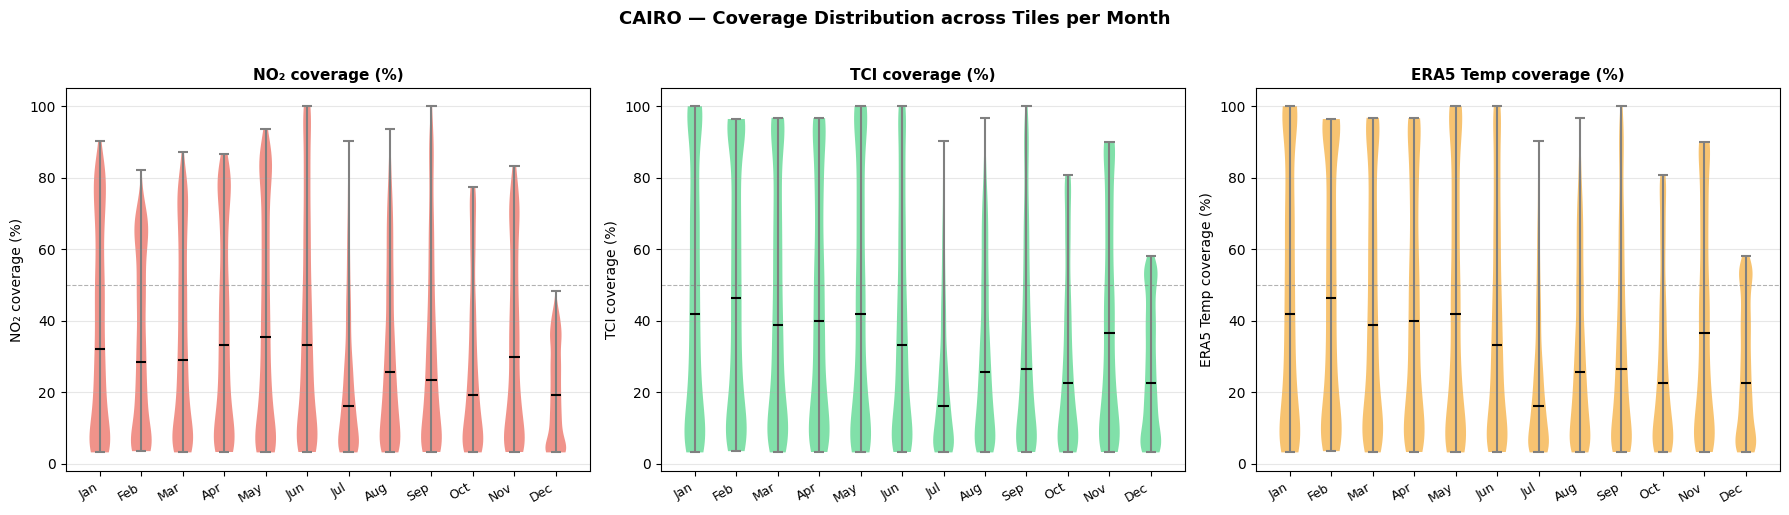

In [8]:
# ── 3.3 Coverage distribution per month (violin plots) ────────────────────────
for city, monthly in all_city_panels.items():

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    month_order = sorted(monthly['month'].unique())
    month_labels = [MONTH_NAMES[m] for m in month_order]

    for ax, col, label, colour in zip(
            axes,
            ['cov_no2_pct', 'cov_tci_pct', 'cov_temp_pct'],
            ['NO₂ coverage (%)', 'TCI coverage (%)', 'ERA5 Temp coverage (%)'],
            ['#e74c3c', '#2ecc71', '#f39c12']):

        data_by_month = [monthly[monthly['month'] == m][col].values for m in month_order]
        vp = ax.violinplot(data_by_month, positions=month_order,
                           showmedians=True, showextrema=True)
        for body in vp['bodies']:
            body.set_facecolor(colour)
            body.set_alpha(0.6)
        vp['cmedians'].set_color('black')
        vp['cmaxes'].set_color('grey')
        vp['cmins'].set_color('grey')
        vp['cbars'].set_color('grey')

        ax.set_xticks(month_order)
        ax.set_xticklabels(month_labels, rotation=30, ha='right', fontsize=9)
        ax.set_ylabel(label, fontsize=10)
        ax.set_ylim(-2, 105)
        ax.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.6)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)

    fig.suptitle(f'{city.upper()} — Coverage Distribution across Tiles per Month',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / city / 'grid_panel' / f'{city}_coverage_violin.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 4. Feature & Target Distributions

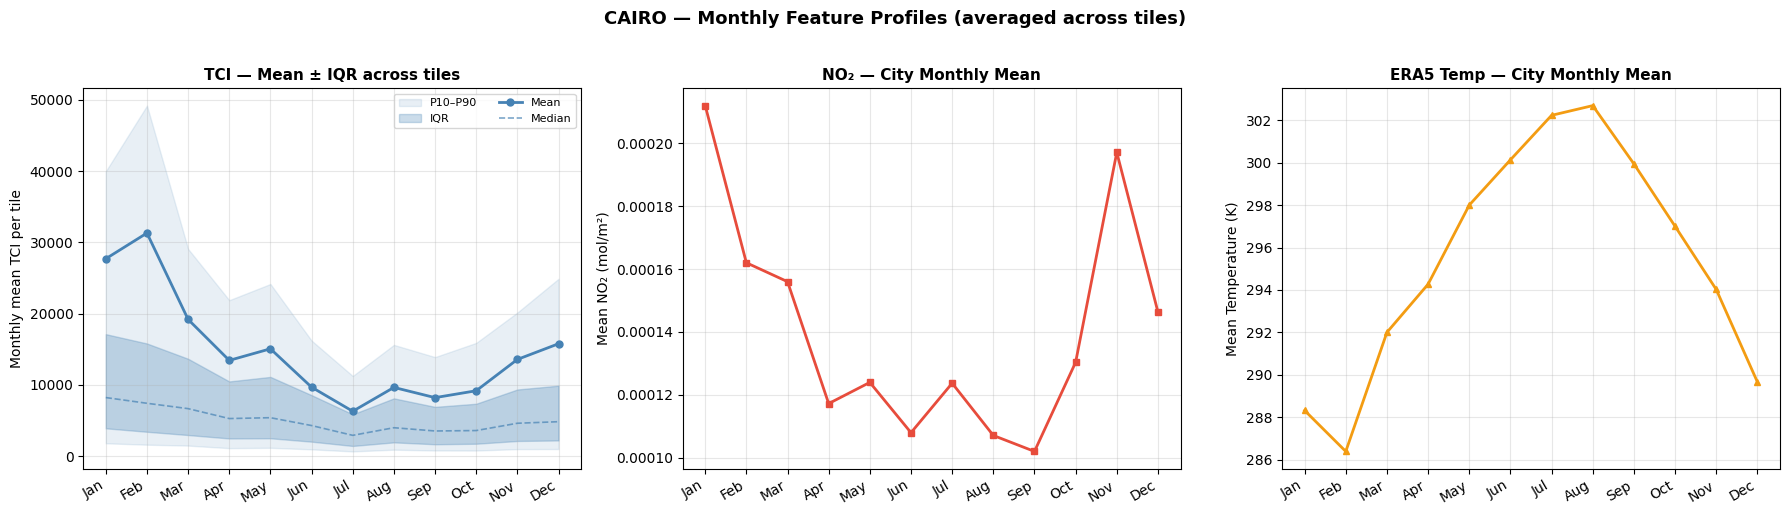

In [9]:
# ── 4.1 Monthly mean TCI per tile — city-level ribbon ─────────────────────────
for city, monthly in all_city_panels.items():

    city_agg = (
        monthly.groupby('month')
        .agg(
            tci_mean   = ('tci', 'mean'),
            tci_median = ('tci', 'median'),
            tci_p25    = ('tci', lambda x: x.quantile(0.25)),
            tci_p75    = ('tci', lambda x: x.quantile(0.75)),
            tci_p10    = ('tci', lambda x: x.quantile(0.10)),
            tci_p90    = ('tci', lambda x: x.quantile(0.90)),
            no2_mean   = ('no2', 'mean'),
            temp_mean  = ('era5_temp', 'mean'),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # TCI
    ax = axes[0]
    ax.fill_between(city_agg['month'], city_agg['tci_p10'], city_agg['tci_p90'],
                    alpha=0.12, color='steelblue', label='P10–P90')
    ax.fill_between(city_agg['month'], city_agg['tci_p25'], city_agg['tci_p75'],
                    alpha=0.28, color='steelblue', label='IQR')
    ax.plot(city_agg['month'], city_agg['tci_mean'],
            color='steelblue', lw=2, marker='o', ms=5, label='Mean')
    ax.plot(city_agg['month'], city_agg['tci_median'],
            color='steelblue', lw=1.2, ls='--', alpha=0.7, label='Median')
    ax.set_xticks(city_agg['month'])
    ax.set_xticklabels([MONTH_NAMES[m] for m in city_agg['month']], rotation=30, ha='right')
    ax.set_ylabel('Monthly mean TCI per tile', fontsize=10)
    ax.set_title('TCI — Mean ± IQR across tiles', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

    # NO₂
    ax = axes[1]
    ax.plot(city_agg['month'], city_agg['no2_mean'],
            color='#e74c3c', lw=2, marker='s', ms=5)
    ax.set_xticks(city_agg['month'])
    ax.set_xticklabels([MONTH_NAMES[m] for m in city_agg['month']], rotation=30, ha='right')
    ax.set_ylabel('Mean NO₂ (mol/m²)', fontsize=10)
    ax.set_title('NO₂ — City Monthly Mean', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Temperature
    ax = axes[2]
    ax.plot(city_agg['month'], city_agg['temp_mean'],
            color='#f39c12', lw=2, marker='^', ms=5)
    ax.set_xticks(city_agg['month'])
    ax.set_xticklabels([MONTH_NAMES[m] for m in city_agg['month']], rotation=30, ha='right')
    ax.set_ylabel('Mean Temperature (K)', fontsize=10)
    ax.set_title('ERA5 Temp — City Monthly Mean', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

    fig.suptitle(f'{city.upper()} — Monthly Feature Profiles (averaged across tiles)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / city / 'grid_panel' / f'{city}_monthly_feature_profiles.png',
                dpi=150, bbox_inches='tight')
    plt.show()

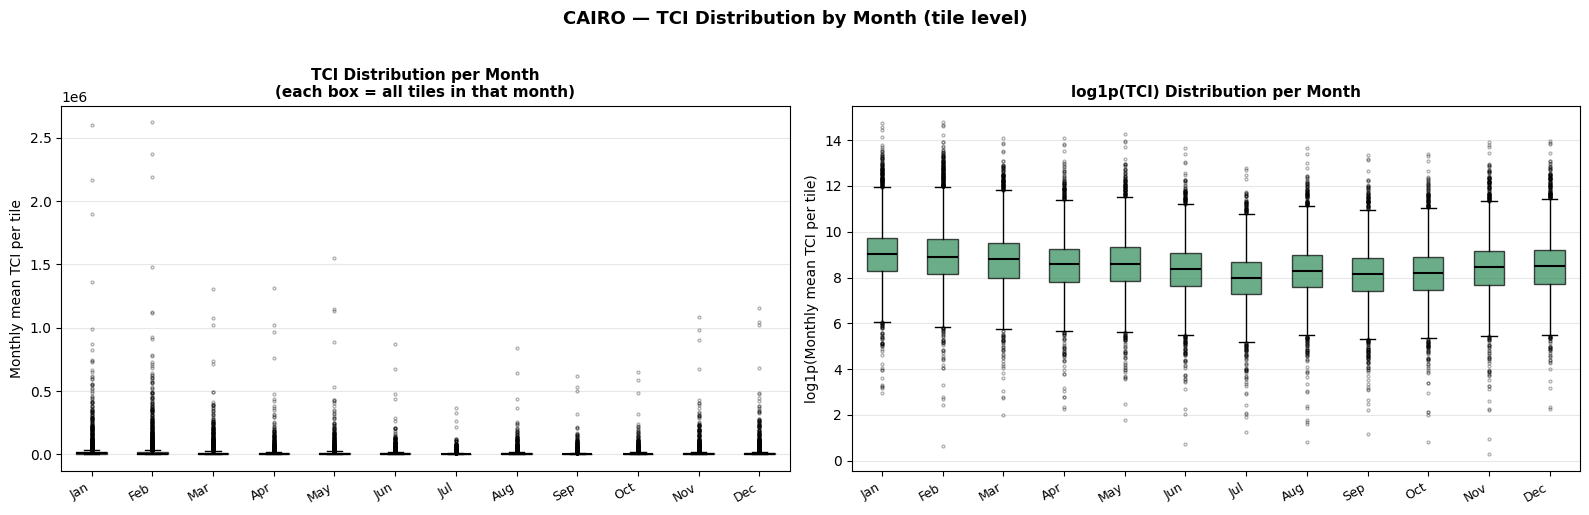

In [10]:
# ── 4.2 TCI distribution per month (boxplots at tile level) ───────────────────
for city, monthly in all_city_panels.items():

    month_order  = sorted(monthly['month'].unique())
    month_labels = [MONTH_NAMES[m] for m in month_order]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Raw TCI
    bp_data = [monthly[monthly['month'] == m]['tci'].values for m in month_order]
    bp = axes[0].boxplot(bp_data, patch_artist=True, notch=False,
                          medianprops=dict(color='black', lw=1.5),
                          flierprops=dict(marker='o', ms=2, alpha=0.3))
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    axes[0].set_xticklabels(month_labels, rotation=30, ha='right', fontsize=9)
    axes[0].set_ylabel('Monthly mean TCI per tile', fontsize=10)
    axes[0].set_title('TCI Distribution per Month\n(each box = all tiles in that month)',
                       fontsize=11, fontweight='bold')
    axes[0].grid(True, axis='y', alpha=0.3)

    # log1p TCI
    bp_log = [np.log1p(monthly[monthly['month'] == m]['tci'].values) for m in month_order]
    bp2 = axes[1].boxplot(bp_log, patch_artist=True, notch=False,
                           medianprops=dict(color='black', lw=1.5),
                           flierprops=dict(marker='o', ms=2, alpha=0.3))
    for patch in bp2['boxes']:
        patch.set_facecolor('seagreen')
        patch.set_alpha(0.7)
    axes[1].set_xticklabels(month_labels, rotation=30, ha='right', fontsize=9)
    axes[1].set_ylabel('log1p(Monthly mean TCI per tile)', fontsize=10)
    axes[1].set_title('log1p(TCI) Distribution per Month',
                       fontsize=11, fontweight='bold')
    axes[1].grid(True, axis='y', alpha=0.3)

    fig.suptitle(f'{city.upper()} — TCI Distribution by Month (tile level)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / city / 'grid_panel' / f'{city}_tci_monthly_boxplot.png',
                dpi=150, bbox_inches='tight')
    plt.show()

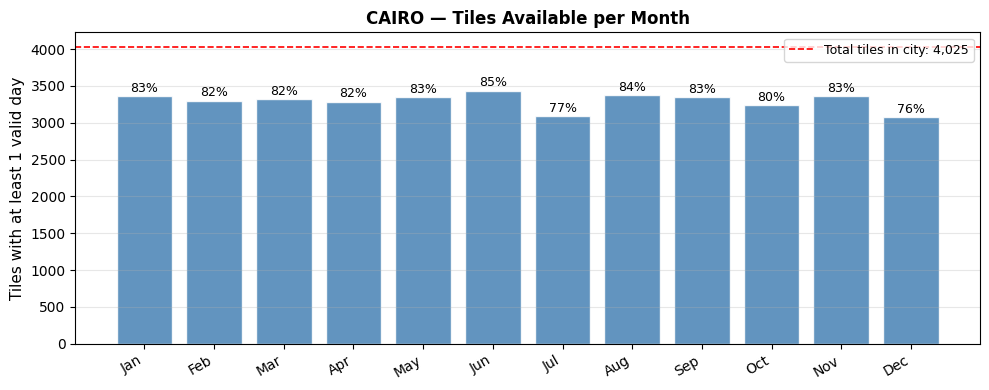

CAIRO — tiles per month:
month_name  n_tiles  pct_of_total
       Jan     3359          83.5
       Feb     3298          81.9
       Mar     3319          82.5
       Apr     3287          81.7
       May     3345          83.1
       Jun     3435          85.3
       Jul     3086          76.7
       Aug     3371          83.8
       Sep     3344          83.1
       Oct     3234          80.3
       Nov     3360          83.5
       Dec     3077          76.4


In [11]:
# ── 4.3 Tile count available per month ────────────────────────────────────────
for city, monthly in all_city_panels.items():

    tile_counts = monthly.groupby('month')[SPATIAL_ID_COL].nunique().reset_index()
    tile_counts.columns = ['month', 'n_tiles']
    total_tiles = monthly[SPATIAL_ID_COL].nunique()

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(tile_counts['month'], tile_counts['n_tiles'],
                  color='steelblue', edgecolor='white', alpha=0.85)
    ax.axhline(total_tiles, color='red', lw=1.2, ls='--',
               label=f'Total tiles in city: {total_tiles:,}')
    ax.set_xticks(tile_counts['month'])
    ax.set_xticklabels([MONTH_NAMES[m] for m in tile_counts['month']],
                        rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('Tiles with at least 1 valid day', fontsize=11)
    ax.set_title(f'{city.upper()} — Tiles Available per Month',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, tile_counts['n_tiles']):
        pct = 100 * val / total_tiles
        ax.text(bar.get_x() + bar.get_width()/2, val + total_tiles * 0.005,
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(DATA_ROOT / city / 'grid_panel' / f'{city}_tiles_per_month.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'{city.upper()} — tiles per month:')
    print(tile_counts.assign(
        month_name=tile_counts['month'].map(MONTH_NAMES),
        pct_of_total=lambda x: (100 * x['n_tiles'] / total_tiles).round(1)
    )[['month_name','n_tiles','pct_of_total']].to_string(index=False))

## 5. Final Panel Summary

In [12]:
for city, monthly in all_city_panels.items():
    print(f'\n═══ {city.upper()} — Final Panel ══════════════════════════════════')
    print(f'  Shape         : {monthly.shape}')
    print(f'  Tiles         : {monthly[SPATIAL_ID_COL].nunique():,}')
    print(f'  Months        : {sorted(monthly["month"].unique())}')
    print(f'  Centroid NaNs : {monthly[["centroid_lon","centroid_lat"]].isna().any(axis=1).sum()}')
    print(f'\n  Descriptive statistics:')
    print(monthly[['no2','era5_temp','tci',
                    'n_days_no2','n_days_tci',
                    'cov_no2_pct','cov_tci_pct']].describe().round(3).to_string())
    print(f'\n  Sample rows:')
    print(monthly.head(3).to_string(index=False))


═══ CAIRO — Final Panel ══════════════════════════════════
  Shape         : (39515, 16)
  Tiles         : 4,025
  Months        : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  Centroid NaNs : 0

  Descriptive statistics:
             no2  era5_temp          tci  n_days_no2  n_days_tci  cov_no2_pct  cov_tci_pct
count  39515.000  39515.000    39515.000   39515.000   39515.000    39515.000    39515.000
mean       0.000    295.407    14961.773       9.945      11.506       32.744       37.937
std        0.000      5.342    57202.510       7.862       9.069       25.893       30.002
min       -0.000    282.227        0.314       1.000       1.000        3.226        3.226
25%        0.000    290.526     2208.125       3.000       3.000        9.677       10.714
50%        0.000    295.872     4809.472       8.000       9.000       25.806       30.000
75%        0.000    300.